In [95]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [96]:
df = pd.read_csv("student_dataset.csv")

In [97]:
df.head()

,Student Name,Problem Solving,Analytical Thinking,Logical Reasoning,Creative Writing,Innovation Challenges,Lateral Thinking,Leadership,Communication Skills,Teamwork,Career Suggestion
0,Sarah Mcconnell,92,52,89,48,44,69,91,63,88,Human Resource Specialist
1,Robert Pope,53,90,41,43,78,95,75,48,85,Financial Analyst
2,Debra Moore,64,42,69,46,64,90,91,92,97,Manager
3,Gary Phillips,74,67,64,99,94,87,55,96,77,Writer
4,Jackie Washington,41,49,83,65,91,42,100,74,91,Entrepreneur


In [148]:
df.describe()

,Problem Solving,Analytical Thinking,Logical Reasoning,Creative Writing,Innovation Challenges,Lateral Thinking,Leadership,Communication Skills,Teamwork
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,70.115500,69.989700,69.834100,70.044500,70.006100,70.113700,69.858500,70.210200,70.274100
std,17.603936,17.647276,17.573983,17.708667,17.630801,17.654527,17.602178,17.461481,17.588039
min,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
25%,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000
50%,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,71.000000
75%,85.000000,85.000000,85.000000,86.000000,85.000000,85.000000,85.000000,85.000000,86.000000
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Problem Solving        10000 non-null  int64 
 1   Analytical Thinking    10000 non-null  int64 
 2   Logical Reasoning      10000 non-null  int64 
 3   Creative Writing       10000 non-null  int64 
 4   Innovation Challenges  10000 non-null  int64 
 5   Lateral Thinking       10000 non-null  int64 
 6   Leadership             10000 non-null  int64 
 7   Communication Skills   10000 non-null  int64 
 8   Teamwork               10000 non-null  int64 
 9   Career Suggestion      10000 non-null  object
dtypes: int64(9), object(1)
memory usage: 781.4+ KB


In [98]:
df.shape

(10000, 11)

In [99]:
df.drop("Student Name", axis = 1, inplace = True)

In [145]:
df['Career Suggestion'].nunique()

9

In [101]:
df.isnull().sum().sum()

0

In [102]:
x = df.drop("Career Suggestion", axis = 1)
y = df['Career Suggestion']

In [103]:
x.corr()

,Problem Solving,Analytical Thinking,Logical Reasoning,Creative Writing,Innovation Challenges,Lateral Thinking,Leadership,Communication Skills,Teamwork
Problem Solving,1.000000,0.015944,-0.001010,0.019313,0.009457,-0.009468,-0.013765,0.007225,0.014801
Analytical Thinking,0.015944,1.000000,0.000869,0.001124,0.002362,-0.017181,0.022015,-0.008944,-0.014107
Logical Reasoning,-0.001010,0.000869,1.000000,0.003939,0.009695,0.003163,0.007854,-0.002595,0.023392
Creative Writing,0.019313,0.001124,0.003939,1.000000,0.005114,0.008837,-0.018699,0.004678,0.015221
Innovation Challenges,0.009457,0.002362,0.009695,0.005114,1.000000,0.006681,-0.003714,-0.000993,-0.017179
Lateral Thinking,-0.009468,-0.017181,0.003163,0.008837,0.006681,1.000000,-0.014038,-0.010217,-0.001703
Leadership,-0.013765,0.022015,0.007854,-0.018699,-0.003714,-0.014038,1.000000,-0.010073,0.005736
Communication Skills,0.007225,-0.008944,-0.002595,0.004678,-0.000993,-0.010217,-0.010073,1.000000,0.013009
Teamwork,0.014801,-0.014107,0.023392,0.015221,-0.017179,-0.001703,0.005736,0.013009,1.000000


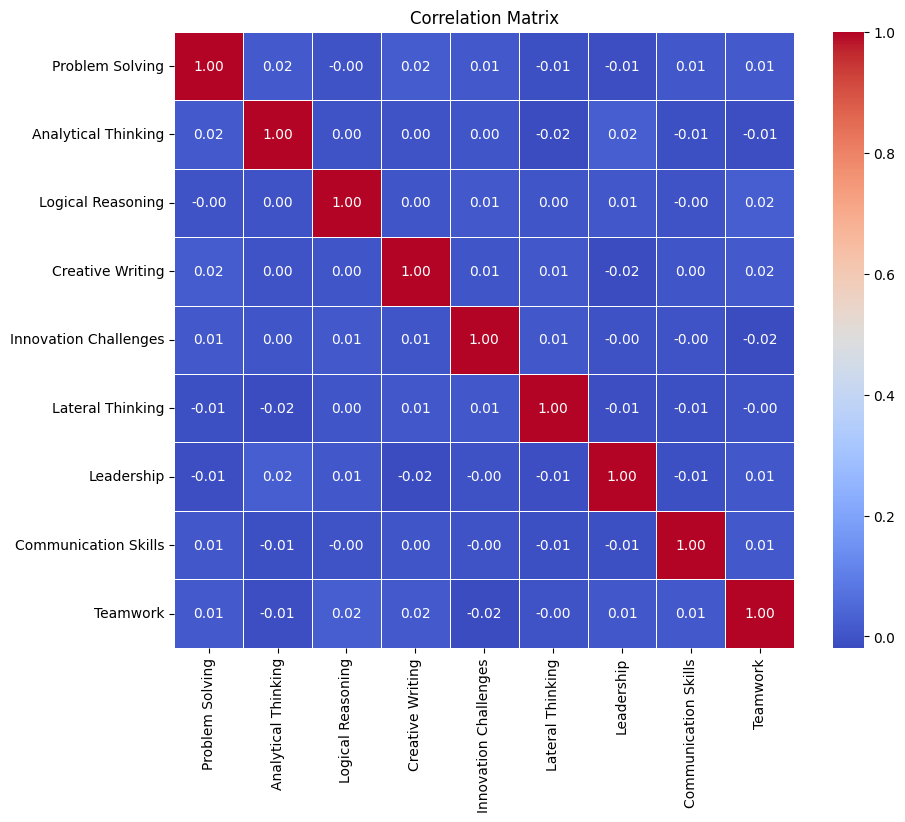

In [104]:
corr_matrix = x.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


In [105]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_copy = y.copy()
y = label_encoder.fit_transform(y)

In [ ]:
['Data Scientist' ,'Enterpreneur' ,'Financial Analyst' ,'Human Resource Specialist' ,'Manager' ,'Marketing Executive' ,'Software Engineer' ,'Teacher' ,'Writer']

SyntaxError: invalid syntax (3544981161.py, line 1)

In [143]:
y[30:40]

array([6, 3, 8, 3, 0, 2, 1, 1, 7, 8])

In [144]:
y_copy[30:40]

30            Software Engineer
31    Human Resource Specialist
32                       Writer
33    Human Resource Specialist
34               Data Scientist
35            Financial Analyst
36                 Entrepreneur
37                 Entrepreneur
38                      Teacher
39                       Writer
Name: Career Suggestion, dtype: object

In [106]:
from sklearn.model_selection import train_test_split

In [107]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state= 43)

In [108]:
from sklearn.preprocessing import StandardScaler

In [109]:
scaler = StandardScaler()

In [110]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [111]:
from sklearn.linear_model import LogisticRegression

In [112]:
lg = LogisticRegression()

In [113]:
lg.fit(x_train_scaled, y_train)

LogisticRegression()

In [114]:
y_pred = lg.predict(x_test_scaled)

In [115]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [116]:
accuracy_score(y_test, y_pred)

0.678

In [117]:
from sklearn.ensemble import RandomForestClassifier

In [118]:
rfc = RandomForestClassifier()

In [119]:
rfc.fit(x_train, y_train)

RandomForestClassifier()

In [120]:
y_pred_rfc = rfc.predict(x_test)

In [121]:
accuracy_score(y_test, y_pred_rfc)

0.792

In [122]:
confusion_matrix(y_test, y_pred_rfc)

array([[290,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0, 352,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,  33,   0,   0,  37,  40,  30,   0],
       [  0,   0,   0, 162,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0, 177,   0,   0,   0,   0],
       [  0,   0,  33,   0,   0,  46,  25,  34,   0],
       [  0,   0,  27,   0,   0,  37,  35,  37,   0],
       [  0,   0,  32,   0,   0,  46,  38,  37,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 452]], dtype=int64)

In [123]:
confusion_matrix(y_test, y_pred)

array([[243,  10,   1,   7,   4,   3,   1,   2,  19],
       [ 14, 316,   0,  10,   9,   0,   0,   0,   3],
       [ 14,  13,  19,   6,  10,  28,  17,  27,   6],
       [  4,   4,   0, 147,   4,   0,   0,   0,   3],
       [  4,  12,   2,  10, 139,   0,   3,   5,   2],
       [  9,  12,  26,   6,   6,  21,  23,  29,   6],
       [  6,  13,  32,   7,   5,  15,  23,  27,   8],
       [  8,  15,  24,  10,   5,  29,  26,  28,   8],
       [ 10,   9,   0,   3,   9,   1,   0,   0, 420]], dtype=int64)

In [124]:
print(classification_report(y_test, y_pred_rfc, target_names=label_encoder.classes_))

                           precision    recall  f1-score   support

           Data Scientist       1.00      1.00      1.00       290
             Entrepreneur       1.00      1.00      1.00       352
        Financial Analyst       0.26      0.24      0.25       140
Human Resource Specialist       1.00      1.00      1.00       162
                  Manager       1.00      1.00      1.00       177
      Marketing Executive       0.28      0.33      0.30       138
        Software Engineer       0.25      0.26      0.26       136
                  Teacher       0.27      0.24      0.25       153
                   Writer       1.00      1.00      1.00       452

                 accuracy                           0.79      2000
                macro avg       0.67      0.67      0.67      2000
             weighted avg       0.79      0.79      0.79      2000



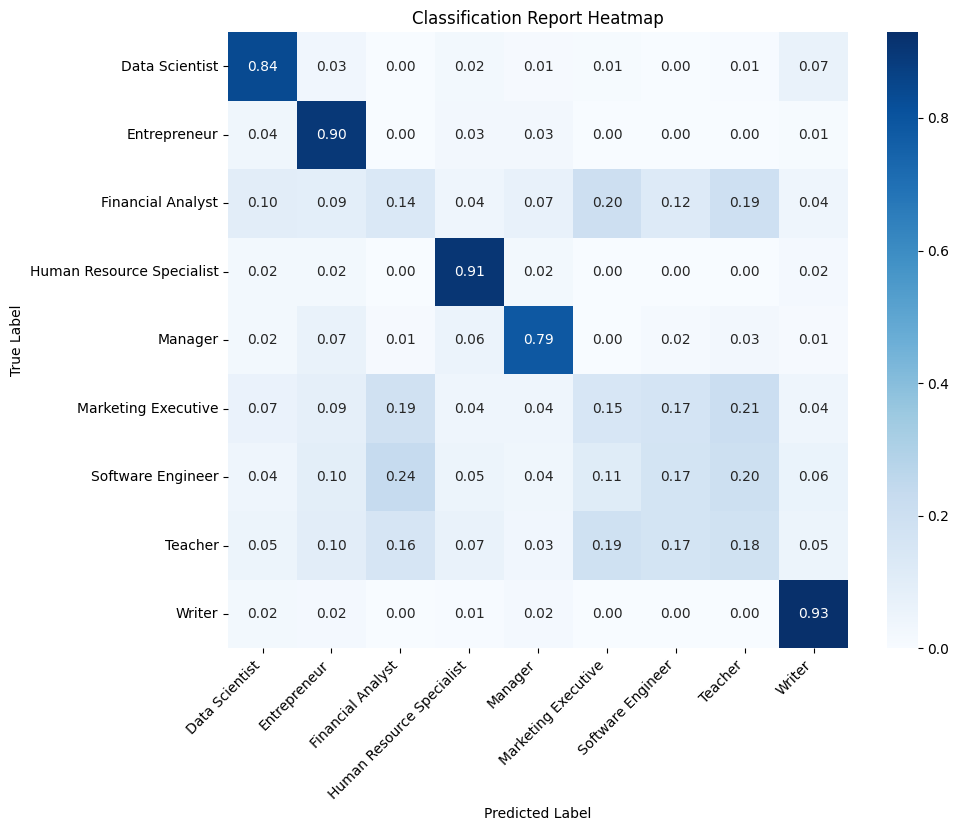

In [125]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Normalize confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Classification Report Heatmap")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()


In [126]:
import pickle
from sklearn.pipeline import Pipeline

In [127]:
pipeline = Pipeline([
    ('model', RandomForestClassifier())
])

In [128]:
pipeline.fit(x_train, y_train)

Pipeline(steps=[('model', RandomForestClassifier())])

In [129]:
y_pred_pipe = pipeline.predict(x_test)

In [130]:
accuracy_score(y_test, y_pred_pipe)

0.79

In [131]:
with open("edtech_model.pkl", "wb") as file:
    pickle.dump(pipeline, file)

In [132]:
x.columns

Index(['Problem Solving', 'Analytical Thinking', 'Logical Reasoning',
       'Creative Writing', 'Innovation Challenges', 'Lateral Thinking',
       'Leadership', 'Communication Skills', 'Teamwork'],
      dtype='object')

In [80]:
import tensorflow as tf 
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

In [80]:
model = Sequential()
# model.add(Dense(1024, activation='relu', input_shape=(x_train.shape[1],)))
# model.add(Dropout(0.2))
# model.add(Dense(512, activation='relu'))
# model.add(Dropout(0.2))
# model.add(Dense(256, activation='relu'))
# model.add(Dropout(0.2))
# model.add(Dense(128, activation='relu'))
model.add(Dense(512, activation='relu', input_shape=(x_train.shape[1],)))
model.add(Dense(256, activation='relu'))
# model.add(Dense(128, activation='relu', input_shape=(x_train.shape[1],)))
model.add(Dense(128, activation='relu'))
# model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
# model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
# model.add(Dropout(0.2))
model.add(Dense(16, activation='relu'))
model.add(Dense(len(label_encoder.classes_), activation='softmax'))

c:\Users\manit\anaconda3\envs\ml\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [81]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [82]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_38 (Dense)                │ (None, 512)            │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 9)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 180,361 (704.54 KB)

 Trainable params: 180,361 (704.54 KB)

 Non-trainable params: 0 (0.00 B)

In [83]:
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

In [84]:
history = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_split = 0.2, verbose=1)


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3610 - loss: 1.9551 - val_accuracy: 0.5788 - val_loss: 1.3246
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5642 - loss: 1.3530 - val_accuracy: 0.6175 - val_loss: 1.1719
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5832 - loss: 1.2296 - val_accuracy: 0.6200 - val_loss: 1.1419
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5990 - loss: 1.1609 - val_accuracy: 0.6338 - val_loss: 1.0674
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6088 - loss: 1.1097 - val_accuracy: 0.6313 - val_loss: 1.0602
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6121 - loss: 1.0808 - val_accuracy: 0.6187 - val_loss: 1.0496
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6186 - loss: 1.0480 - val_accuracy: 0.6137 - val_loss: 1.0697
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6325 - loss: 1.0189 - val_accu

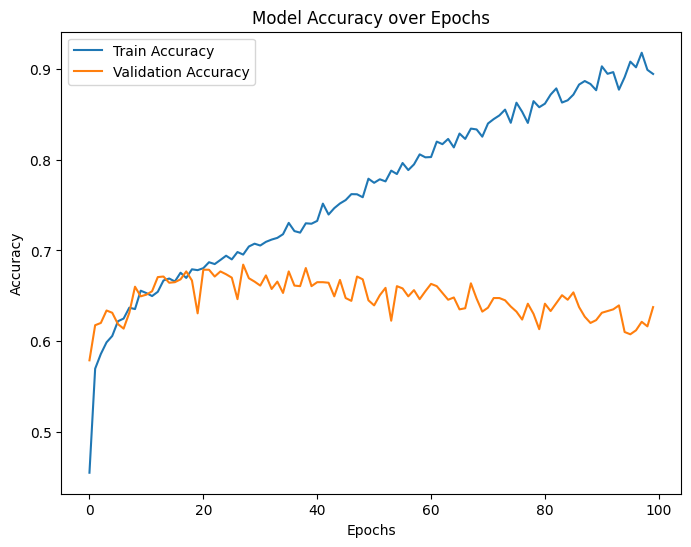

In [85]:

# Plot training history
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy over Epochs')
plt.legend()
plt.show()
